In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
df = pd.read_csv('/Users/manurajgoel/Desktop/MLPRACTICAL/PROJECTS/car details v4.csv')
df.head()

,Make,Model,Price,Year,Kilometer,Fuel Type,Transmission,Location,Color,Owner,Seller Type,Engine,Max Power,Max Torque,Drivetrain,Length,Width,Height,Seating Capacity,Fuel Tank Capacity
0,Honda,Amaze 1.2 VX i-VTEC,505000,2017,87150,Petrol,Manual,Pune,Grey,First,Corporate,1198 cc,87 bhp @ 6000 rpm,109 Nm @ 4500 rpm,FWD,3990.0,1680.0,1505.0,5.0,35.0
1,Maruti Suzuki,Swift DZire VDI,450000,2014,75000,Diesel,Manual,Ludhiana,White,Second,Individual,1248 cc,74 bhp @ 4000 rpm,190 Nm @ 2000 rpm,FWD,3995.0,1695.0,1555.0,5.0,42.0
2,Hyundai,i10 Magna 1.2 Kappa2,220000,2011,67000,Petrol,Manual,Lucknow,Maroon,First,Individual,1197 cc,79 bhp @ 6000 rpm,112.7619 Nm @ 4000 rpm,FWD,3585.0,1595.0,1550.0,5.0,35.0
3,Toyota,Glanza G,799000,2019,37500,Petrol,Manual,Mangalore,Red,First,Individual,1197 cc,82 bhp @ 6000 rpm,113 Nm @ 4200 rpm,FWD,3995.0,1745.0,1510.0,5.0,37.0
4,Toyota,Innova 2.4 VX 7 STR [2016-2020],1950000,2018,69000,Diesel,Manual,Mumbai,Grey,First,Individual,2393 cc,148 bhp @ 3400 rpm,343 Nm @ 1400 rpm,RWD,4735.0,1830.0,1795.0,7.0,55.0


In [3]:
df.shape
# tells the number of rows and columns

(2059, 20)

In [4]:
df.info()
# tells which column is numerical and which is categorical
# it also tells the missing values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2059 entries, 0 to 2058
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Make                2059 non-null   object 
 1   Model               2059 non-null   object 
 2   Price               2059 non-null   int64  
 3   Year                2059 non-null   int64  
 4   Kilometer           2059 non-null   int64  
 5   Fuel Type           2059 non-null   object 
 6   Transmission        2059 non-null   object 
 7   Location            2059 non-null   object 
 8   Color               2059 non-null   object 
 9   Owner               2059 non-null   object 
 10  Seller Type         2059 non-null   object 
 11  Engine              1979 non-null   object 
 12  Max Power           1979 non-null   object 
 13  Max Torque          1979 non-null   object 
 14  Drivetrain          1923 non-null   object 
 15  Length              1995 non-null   float64
 16  Width 

In [5]:
df.describe()
# helps detect OUTLIERS and wrong values(eg negative km)

,Price,Year,Kilometer,Length,Width,Height,Seating Capacity,Fuel Tank Capacity
count,2.059000e+03,2059.000000,2.059000e+03,1995.000000,1995.000000,1995.000000,1995.000000,1946.000000
mean,1.702992e+06,2016.425449,5.422471e+04,4280.860652,1767.991980,1591.735338,5.306266,52.002210
std,2.419881e+06,3.363564,5.736172e+04,442.458507,135.265825,136.073956,0.822170,15.110198
min,4.900000e+04,1988.000000,0.000000e+00,3099.000000,1475.000000,1165.000000,2.000000,15.000000
25%,4.849990e+05,2014.000000,2.900000e+04,3985.000000,1695.000000,1485.000000,5.000000,41.250000
50%,8.250000e+05,2017.000000,5.000000e+04,4370.000000,1770.000000,1545.000000,5.000000,50.000000
75%,1.925000e+06,2019.000000,7.200000e+04,4629.000000,1831.500000,1675.000000,5.000000,60.000000
max,3.500000e+07,2022.000000,2.000000e+06,5569.000000,2220.000000,1995.000000,8.000000,105.000000


In [6]:
# DISPLAYING MISSING VALUES
# counts missing values per column
# we must remove or fill them before modelling

df.isnull().sum().sort_values(ascending=False)

Drivetrain            136
Fuel Tank Capacity    113
Max Torque             80
Max Power              80
Engine                 80
Seating Capacity       64
Height                 64
Width                  64
Length                 64
Model                   0
Make                    0
Owner                   0
Color                   0
Location                0
Transmission            0
Fuel Type               0
Kilometer               0
Year                    0
Price                   0
Seller Type             0
dtype: int64

In [7]:
# FEATURE SELECTION
# dropping unnecessary columns
# some columns add noise, cause overfitting etc

df.drop(columns=['Color', 'Location'], inplace=True)

# Color -> has very week effect on price
# Location -> noisy, city bias

# In this we are not removing model as it can affect price of the car
# better model -> more price

In [8]:
# FEATURE ENGINEERING
# We can convert the model YEAR into CAR AGE

df['Car_Age'] = 2026 - df['Year']
df.drop(columns='Year', inplace=True)

In [9]:
# CLEANING ENGINE 

# 1198 cc to 1198
# convert text into numeric

df['Engine'] = df['Engine'].str.replace(' cc', '')
# .str.replcae() removes text

df['Engine'] = df['Engine'].astype(float)
# .astype(float) converts string into number

In [10]:
# CLEAN MAX POWER
# (87 bhp @ 6000 rpm)

df['Max Power'] = df['Max Power'].str.extract(r'(\d+\.?\d*)')
# regex extracts only the number

df['Max Power'] = df['Max Power'].astype(float)
# converts bhp into numeric value

In [11]:
# CLEAN MAX TORQUE

df['Max Torque'] = df['Max Torque'].str.extract(r'(\d+\.?\d*)')
# regex extracts only the number

df['Max Torque'] = df['Max Torque'].astype(float)
# torque strongly influences car performance & price

In [12]:
df.isnull().sum().sort_values(ascending=False)

Drivetrain            136
Fuel Tank Capacity    113
Max Power              80
Max Torque             80
Engine                 80
Seating Capacity       64
Height                 64
Width                  64
Length                 64
Make                    0
Model                   0
Seller Type             0
Owner                   0
Transmission            0
Fuel Type               0
Kilometer               0
Price                   0
Car_Age                 0
dtype: int64

In [13]:
# we need to treat numerical and categorical columns differently

# filling NUMERICAL columns with MEDIAN

num_cols = df.select_dtypes(include = ['float64', 'int64']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

In [14]:
# filling CATEGORICAL columns with mode

cat_cols = df.select_dtypes(include='object').columns
df[cat_cols] = df[cat_cols].fillna(df[cat_cols].mode().iloc[0])

In [15]:
df.isnull().sum()

Make                  0
Model                 0
Price                 0
Kilometer             0
Fuel Type             0
Transmission          0
Owner                 0
Seller Type           0
Engine                0
Max Power             0
Max Torque            0
Drivetrain            0
Length                0
Width                 0
Height                0
Seating Capacity      0
Fuel Tank Capacity    0
Car_Age               0
dtype: int64

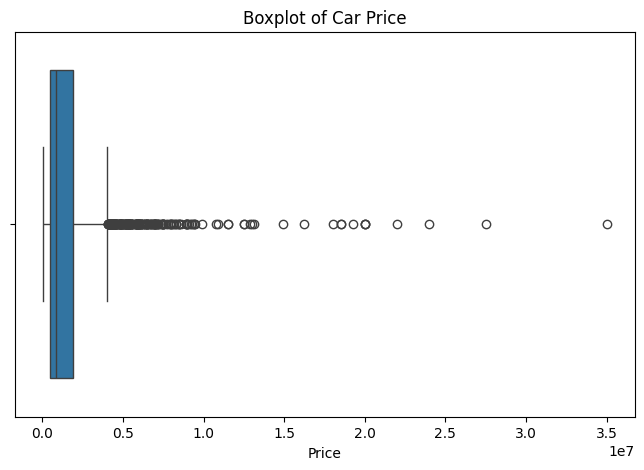

In [16]:
# BOXPLOT  -> showing outliers for price

plt.figure(figsize=(8,5))
sns.boxplot(x=df['Price'])
plt.title("Boxplot of Car Price")
plt.xlabel("Price")
plt.show()

In [17]:
# Removing Price Outliers (IQR method)

Q1 = df['Price'].quantile(0.25)
Q3 = df['Price'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df['Price'] >= lower) & (df['Price'] <= upper)]


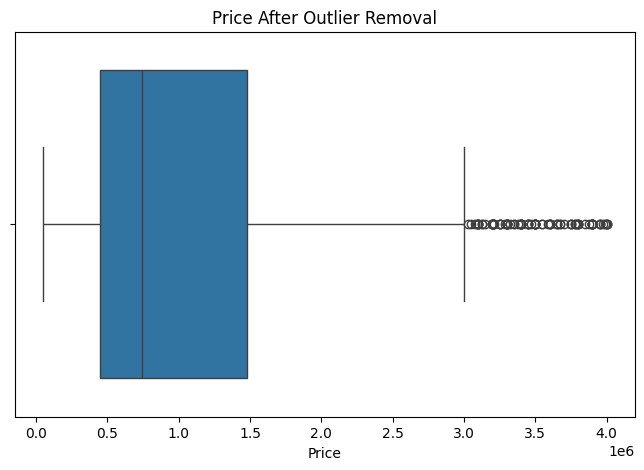

In [18]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Price'])
plt.title("Price After Outlier Removal")
plt.xlabel("Price")
plt.show()

In [19]:
# separate features(X) and target(y)

X = df.drop('Price', axis=1)

# scaling is for input features(X), not the target(y)

# log transform target
y = np.log1p(df['Price'])

# log1p() helps handle skewed price values
# We used log on price because it reduces skewness and large outlier effects
# log1p() means log(1+x)

In [20]:
# ENCODING CATEGORICAL FEATURES

X = pd.get_dummies(X , drop_first=True)

# WORKING:
# 1. Finds all categorical(object) columns
# 2. Converts each category into binary(¯0/1)

# encoding increases number of columns
# eg : Fuel Type_Diesel, Transmission_Manual, Make_Hyundai etc

X.shape

(1844, 997)

In [21]:
# TRAIN-TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(X,
    y,
    test_size=0.2,
    random_state=42
)

In [22]:
# FEATURE SCALING
# StandardScaler makes all feature values come to a similar range, 
# so the model can learn fairly and better.

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [23]:
# LINEAR REGRESSION

from sklearn.linear_model import LinearRegression

linear = LinearRegression()
linear.fit(X_train_scaled, y_train)

y_pred_log = linear.predict(X_test_scaled)

y_test_actual = np.expm1(y_test)
y_pred_actual = np.expm1(y_pred_log)

print("R²:", r2_score(y_test_actual, y_pred_actual))
print("MAE:", mean_absolute_error(y_test_actual, y_pred_actual))
print("RMSE:", np.sqrt(mean_squared_error(y_test_actual, y_pred_actual)))

R²: -4.312882927428985
MAE: 562114.6740031387
RMSE: 1984283.7101622738


In [24]:
# RIDGE REGRESSION

from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

ridge = Ridge()

params = {
    'alpha': [0.01, 0.1, 1, 10, 50, 100, 200]
}

grid = GridSearchCV(ridge, params, cv=5, scoring='r2', n_jobs=-1)
grid.fit(X_train_scaled, y_train)

best_ridge = grid.best_estimator_

y_pred_log = best_ridge.predict(X_test_scaled)

y_test_actual = np.expm1(y_test)
y_pred_actual = np.expm1(y_pred_log)

print("Best Alpha:", grid.best_params_)
print("R²:", r2_score(y_test_actual, y_pred_actual))
print("MAE:", mean_absolute_error(y_test_actual, y_pred_actual))
print("RMSE:", np.sqrt(mean_squared_error(y_test_actual, y_pred_actual)))

Best Alpha: {'alpha': 10}
R²: 0.7807644674751835
MAE: 199476.20360954854
RMSE: 403082.660003225


In [25]:
# LASSSO REGRESSION

from sklearn.linear_model import Lasso

lasso = Lasso(max_iter=20000)

params = {
    'alpha': [0.0001, 0.001, 0.01, 0.1, 1]
}

grid = GridSearchCV(
    lasso,
    params,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid.fit(X_train_scaled, y_train)

best_lasso = grid.best_estimator_

y_pred_log = best_lasso.predict(X_test_scaled)

y_test_actual = np.expm1(y_test)
y_pred_actual = np.expm1(y_pred_log)

print("Best Alpha:", grid.best_params_)
print("R²:", r2_score(y_test_actual, y_pred_actual))
print("MAE:", mean_absolute_error(y_test_actual, y_pred_actual))
print("RMSE:", np.sqrt(mean_squared_error(y_test_actual, y_pred_actual)))

Best Alpha: {'alpha': 0.001}
R²: 0.666812100500134
MAE: 187251.71219571176
RMSE: 496916.3131687987


In [26]:
# ELASTICNET REGRESSION

from sklearn.linear_model import ElasticNet

elastic = ElasticNet(
    alpha=0.001,
    l1_ratio=0.5,
    max_iter=20000
)

elastic.fit(X_train_scaled, y_train)

y_pred_log = elastic.predict(X_test_scaled)

y_test_actual = np.expm1(y_test)
y_pred_actual = np.expm1(y_pred_log)

print("R²:", r2_score(y_test_actual, y_pred_actual))
print("MAE:", mean_absolute_error(y_test_actual, y_pred_actual))
print("RMSE:", np.sqrt(mean_squared_error(y_test_actual, y_pred_actual)))

R²: 0.832954686729348
MAE: 173412.39973204912
RMSE: 351848.5711461243


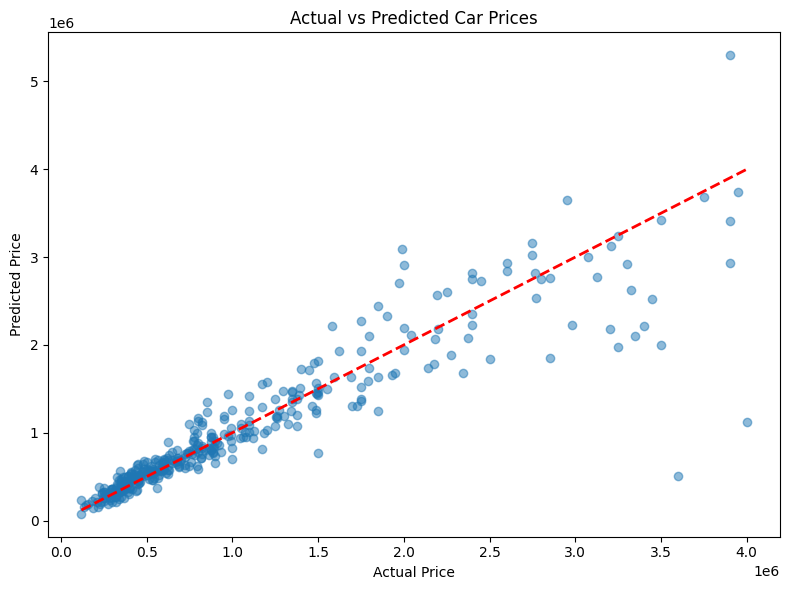

In [28]:
plt.figure(figsize=(8,6))

plt.scatter(y_test_actual, y_pred_actual, alpha=0.5)

plt.plot(
    [y_test_actual.min(), y_test_actual.max()],
    [y_test_actual.min(), y_test_actual.max()],
    'r--',
    lw=2
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Car Prices")
plt.tight_layout()
plt.show()